# Qwen2.5-VL-3B Model Evaluation

This notebook evaluates the performance of Qwen2.5-VL-3B model on our fire detection dataset.

In [1]:
# For virtual environment only, ignore this cell if you're using personal computer
!source ../../miniconda3/bin/activate
!conda --version

conda 24.11.3


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import pandas as pd
import numpy as np
from PIL import Image
import torch
from transformers import AutoTokenizer, AutoProcessor, Qwen2_5_VLForConditionalGeneration
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time
import re, json

In [3]:
# Load ground truth data
df = pd.read_csv('../test_labels.csv')
print(f"Total samples in dataset: {len(df)}")
df.head()

Total samples in dataset: 1290


,image_path,label,caption
0,fine_tune_dataset/test/images/test_1.jpg,dangerous fire,The image shows a close-up view of an electric...
1,fine_tune_dataset/test/images/test_2.jpg,controlled fire,"The image shows a narrow, dark tunnel with a b..."
2,fine_tune_dataset/test/images/test_3.jpg,controlled fire,The image shows a nighttime camping scene with...
3,fine_tune_dataset/test/images/test_4.jpg,controlled fire,A piece of paper is being burned on a white pl...
4,fine_tune_dataset/test/images/test_5.jpg,no fire,The image shows a small room with a white wall...


In [6]:
import base64
import json
import time
import re
from openai import OpenAI

# Initialize client (assumes OpenAI-compatible local server like llama-cpp, LM Studio, etc.)
client = OpenAI(base_url="http://127.0.0.1:8080/v1", api_key="sk-test", timeout=9999)

system_message = """You are a Vision Language Model specialized in detecting clues of fire, smoke and surrounding context then classify them as no fire, dangerous fire or controlled fire.
Your task is to analyze the provided image and respond to queries with concise answers, usually a json format of a caption and a label.
Summarize what you see in the image. Describe the environment, key objects, people, and any signs of fire or smoke.
Based on your summary, classify the fire situation: no fire(e.g., fire alarm, fire distinguisher,..), controlled fire (e.g., fireplace emitting, campfire, cooking, candles, match stick, lighter..) or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire on furniture..)
Focus on delivering accurate, succinct caption and precise label based on the visual information. Add a brief explanation for your choice of label in the caption if necessary."""

user_query = """Summarize this situation in the image, look for signs of fire and smoke and classify whether the situation is 
no fire(e.g., fire alarm, fire distinguisher,..), 
controlled fire (e.g., fireplace emitting, campfire, cooking, candles, match stick, lighter..) 
or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire on furniture..)
Add a brief explanation for your choice of label in the caption if necessary.
Respond only this json format:
{ "caption": "...", "label": "no fire"|"controlled fire"|"dangerous fire" }
"""

def encode_image(image_path):
    with open(image_path, "rb") as f:
        base64_bytes = base64.b64encode(f.read()).decode("utf-8")
    return f"data:image/jpeg;base64,{base64_bytes}"

def process_image(image_path):
    try:
        start_time = time.time()

        data_url = encode_image(image_path)

        response = client.chat.completions.create(
            model="gpt-4o",
            temperature=0.1,
            stream=True,
            messages=[
                {
                    "role": "system",
                    "content": [{"type": "text", "text": system_message}]
                },
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": user_query},
                        {"type": "image_url", "image_url": {"url": data_url}},
                    ]
                }
            ]
        )

        # Collect streamed output
        full_output = ""
        for chunk in response:
            delta = chunk.choices[0].delta.content
            if delta:
                full_output += delta
                
        # Extract JSON from output
        json_str = re.sub(r"^```json|```$", "", full_output.strip(), flags=re.MULTILINE).strip()
        result = json.loads(json_str)
        label = result["label"]
        caption = result["caption"]
        inference_time = time.time() - start_time

        return label, caption, inference_time

    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return "no fire", "failed to generate caption", 0.0


In [7]:
# Process all images and collect predictions
predictions = []
captions = []
inference_times = []
ground_truth = []

for idx, row in df.iterrows():
    img_path = os.path.join('../',row['image_path'])
    if os.path.exists(img_path):
        pred, caption, inf_time = process_image(img_path)
        predictions.append(pred)
        captions.append(caption)
        inference_times.append(inf_time)
        ground_truth.append(row['label'])
        print(f"{img_path}: {pred}, truth: {row['label']}, caption: {caption}")
        if idx % 10 == 0:
             print(f"Processed {idx} images... Average inference time so far: {np.mean(inference_times):.3f}s")

print(f"\nProcessing complete! Average inference time: {np.mean(inference_times):.3f}s")

../fine_tune_dataset/test/images/test_1.jpg: dangerous fire, truth: dangerous fire, caption: The image shows a close-up of a device with wires and a small flame or smoke coming from it. The wires are connected to a circuit board, and there is a small flame or smoke emanating from the device.
Processed 0 images... Average inference time so far: 2.365s
../fine_tune_dataset/test/images/test_2.jpg: dangerous fire, truth: controlled fire, caption: A person is walking through a dimly lit hallway with a bright light source at the end, possibly a fire or a lamp.
../fine_tune_dataset/test/images/test_3.jpg: controlled fire, truth: controlled fire, caption: A tent is lit up by a campfire in the night sky, surrounded by trees.
../fine_tune_dataset/test/images/test_4.jpg: controlled fire, truth: controlled fire, caption: 一张纸放在白色盘子上，纸张边缘有火焰。
../fine_tune_dataset/test/images/test_5.jpg: controlled fire, truth: no fire, caption: A small candle is lit on a table, emitting a faint flame and smoke. The 

In [8]:
# Calculate metrics
accuracy = accuracy_score(ground_truth, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    ground_truth,
    predictions,
    average='weighted'
)

print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"\nInference Time Statistics:")
print(f"Average: {np.mean(inference_times):.3f}s")
print(f"Std Dev: {np.std(inference_times):.3f}s")
print(f"Min: {np.min(inference_times):.3f}s")
print(f"Max: {np.max(inference_times):.3f}s")

Model Performance Metrics:
Accuracy: 0.6202
Precision: 0.6885
Recall: 0.6202
F1 Score: 0.6235

Inference Time Statistics:
Average: 1.894s
Std Dev: 0.255s
Min: 0.788s
Max: 3.707s


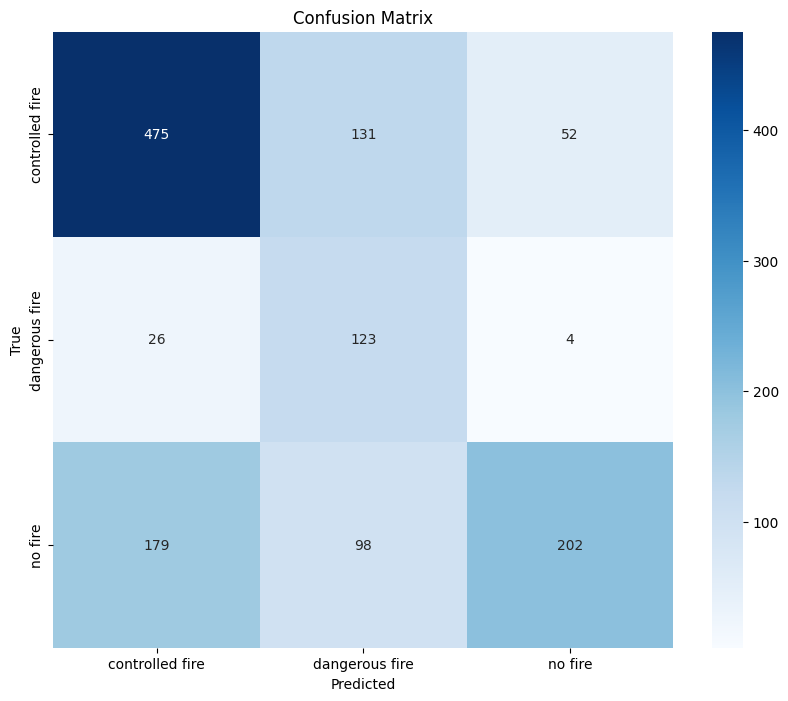

In [9]:
# Create and plot confusion matrix
labels = sorted(list(set(ground_truth)))
cm = confusion_matrix(ground_truth, predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Results saved to qwen2.5_vl_3B_results.csv


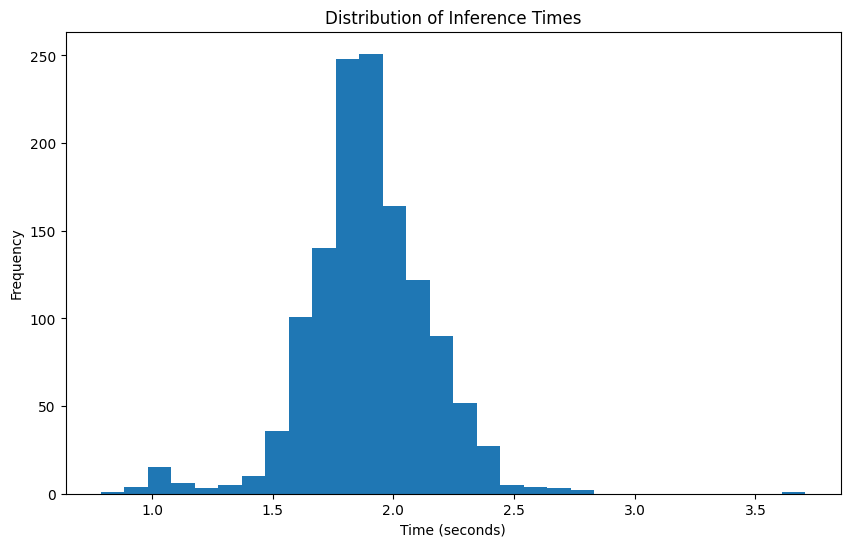

In [10]:
# Save results to CSV
results_df = pd.DataFrame({
    'image_path': df['image_path'],
    'true_label': ground_truth,
    'predicted_label': predictions,
    'caption': captions,
    'inference_time': inference_times,
    'correct': [t == p for t, p in zip(ground_truth, predictions)]
})

results_df.to_csv('qwen2.5_vl_3B_results.csv', index=False)
print("Results saved to qwen2.5_vl_3B_results.csv")

# Display inference time distribution
plt.figure(figsize=(10, 6))
plt.hist(inference_times, bins=30)
plt.title('Distribution of Inference Times')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.show()